# Olist Delivery Delay Prediction — Business-First Model

**Main goal:** Flag the riskiest orders *before* they become late, so operations can intervene.

**Not the main goal:** High overall accuracy (easy when ~95% of orders are on-time).

**Models compared (same time-based test set)**
1. XGBoost
2. CatBoost
3. Random Forest
4. Neural Network (MLP)
5. Logistic Regression (baseline)

**How the best model is chosen**
- Primary: **Lift @ top 10%** (business ranking quality)
- Secondary: **PR-AUC** (precision-recall under imbalance)
- Tie-break: ROC-AUC

**Also includes**
- Walk-forward validation
- Regression (days late)
- Ranked delay risk report
- Category / route / seller insight tables

**Data:** Brazilian E-Commerce (Olist) public dataset on Kaggle.


## 1. Setup

In [4]:
import os, sys, glob, warnings, json, subprocess
warnings.filterwarnings("ignore")
print("Python:", sys.version)

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["xgboost", "shap", "optuna", "statsmodels", "catboost"]:
    try:
        __import__(pkg)
    except ImportError:
        pip_install(pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
print("Libraries ready")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Libraries ready


## 2. Load Data

In [5]:
def find_csv(keywords, exclude=None):
    if isinstance(keywords, str):
        keywords = [keywords]
    all_csvs = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    for kw in keywords:
        for path in all_csvs:
            fname = os.path.basename(path).lower()
            if kw in fname and (exclude is None or exclude not in fname):
                return path
    raise FileNotFoundError(f"No CSV found for keywords={keywords}")

FILES = {
    "customers":            find_csv(["customer", "cusomter", "custome"]),
    "geolocation":          find_csv("geolocation"),
    "order_items":          find_csv("order_item"),
    "payments":             find_csv("payment"),
    "reviews":              find_csv("review"),
    "orders":               find_csv("orders"),
    "products":             find_csv("product", exclude="category"),
    "sellers":              find_csv("seller"),
    "category_translation": find_csv("category_name_translation"),
}
for k, v in FILES.items():
    print(f"{k:22s} -> {os.path.basename(v)}")

customers = pd.read_csv(FILES["customers"])
orders = pd.read_csv(FILES["orders"], parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"])
order_items = pd.read_csv(FILES["order_items"], parse_dates=["shipping_limit_date"])
payments = pd.read_csv(FILES["payments"])
reviews = pd.read_csv(FILES["reviews"], parse_dates=["review_creation_date", "review_answer_timestamp"])
products = pd.read_csv(FILES["products"])
sellers = pd.read_csv(FILES["sellers"])
cat_trans = pd.read_csv(FILES["category_translation"])
geolocation = pd.read_csv(FILES["geolocation"])
print("\nLoaded. Orders shape:", orders.shape)


customers              -> cusomters_dataset.csv
geolocation            -> geolocation_dataset.csv
order_items            -> order_items_dataset.csv
payments               -> order_payments_dataset.csv
reviews                -> order_reviews_dataset.csv
orders                 -> orders_dataset.csv
products               -> products_dataset.csv
sellers                -> sellers_dataset.csv
category_translation   -> product_category_name_translation.csv

Loaded. Orders shape: (99441, 9)


## 3. Data Quality — Fix Placeholder Dates

In [6]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    bad = orders[col].dt.year <= 1901
    if bad.any():
        orders.loc[bad, col] = pd.NaT
        print(f"Fixed {bad.sum()} placeholder dates in {col}")
print("Orders shape:", orders.shape)


Orders shape: (99441, 9)


## 4. Master Table & Feature Engineering

Key features:
- `carrier_pickup_days` — seller handling time (strong predictor)
- `seller_hist_late_rate` / `seller_recent_late_rate` (30-day, leakage-safe)
- Haversine distance, order item count, promised delivery window, etc.


In [7]:
products = products.merge(cat_trans, on="product_category_name", how="left")
products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"]).fillna("unknown")
)

payments_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    n_payment_installments=("payment_installments", "max"),
    main_payment_type=("payment_type", lambda s: s.value_counts().idxmax())
).reset_index()

reviews_latest = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]]
)
order_item_counts = (
    order_items.groupby("order_id")["order_item_id"].count()
    .rename("order_item_count").reset_index()
)

df = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products[["product_id", "product_category_name_english",
                     "product_weight_g", "product_photos_qty"]], on="product_id", how="left")
    .merge(sellers[["seller_id", "seller_state", "seller_zip_code_prefix"]], on="seller_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_latest, on="order_id", how="left")
    .merge(order_item_counts, on="order_id", how="left")
)
df = df.rename(columns={"product_category_name_english": "category"})

df["freight_ratio"] = df["freight_value"] / df["price"].replace(0, np.nan)
df["order_value"] = df["price"] + df["freight_value"]
df["delivery_delay_days"] = (
    (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"])
    .dt.total_seconds() / 86400
)
df["is_late"] = (df["delivery_delay_days"] > 0).astype("Int64")
df["approval_days"] = (
    (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400
)
df["carrier_pickup_days"] = (
    (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds() / 86400
)
df["promised_delivery_days"] = (
    (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"])
    .dt.total_seconds() / 86400
)
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_dow"] = df["order_purchase_timestamp"].dt.dayofweek
df["order_year"] = df["order_purchase_timestamp"].dt.year
df["order_hour"] = df["order_purchase_timestamp"].dt.hour
df["is_weekend"] = df["purchase_dow"].isin([5, 6]).astype(int)
df["is_holiday_season"] = df["purchase_month"].isin([11, 12]).astype(int)
df["freight_percentage"] = df["freight_value"] / df["order_value"].replace(0, np.nan)

df_model = df[df["order_status"] == "delivered"].copy()
df_model = df_model.dropna(subset=["is_late", "price", "freight_value", "delivery_delay_days"])
df_model = df_model.sort_values("order_purchase_timestamp").reset_index(drop=True)
print("Delivered orders:", df_model.shape)
print("Late rate: {:.1%}".format(df_model["is_late"].mean()))


Delivered orders: (110189, 45)
Late rate: 7.9%


## 5. Geo Distance & Seller History (Leakage-Safe)

In [8]:
geo_lookup = geolocation.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean")
).reset_index()

df_model = df_model.merge(
    geo_lookup.rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix",
                               "lat": "cust_lat", "lng": "cust_lng"}),
    on="customer_zip_code_prefix", how="left")
df_model = df_model.merge(
    geo_lookup.rename(columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix",
                               "lat": "seller_lat", "lng": "seller_lng"}),
    on="seller_zip_code_prefix", how="left")

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_model["customer_seller_distance_km"] = haversine_km(
    df_model["cust_lat"], df_model["cust_lng"],
    df_model["seller_lat"], df_model["seller_lng"]
)
df_model["distance_category"] = pd.cut(
    df_model["customer_seller_distance_km"],
    bins=[-np.inf, 100, 500, 1000, np.inf],
    labels=["Short", "Medium", "Long", "Very Long"]
).astype(str)

df_model = df_model.sort_values("order_purchase_timestamp").reset_index(drop=True)

df_model["seller_hist_late_rate"] = (
    df_model.groupby("seller_id")["is_late"]
    .apply(lambda s: s.shift().expanding().mean())
    .reset_index(level=0, drop=True)
)
df_model["seller_hist_n_orders"] = df_model.groupby("seller_id").cumcount()

def rolling_recent_rate(group):
    s = group.set_index("order_purchase_timestamp")["is_late"]
    return s.shift().rolling("30D").mean()

recent = df_model.groupby("seller_id", group_keys=False).apply(rolling_recent_rate)
df_model["seller_recent_late_rate"] = recent.values

global_late = df_model["is_late"].mean()
df_model["seller_is_new"] = df_model["seller_hist_n_orders"].eq(0).astype(int)
df_model["seller_hist_late_rate"] = df_model["seller_hist_late_rate"].fillna(global_late)
df_model["seller_recent_late_rate"] = df_model["seller_recent_late_rate"].fillna(
    df_model["seller_hist_late_rate"]
)

order_level = (
    df_model.drop_duplicates("order_id")[["order_id", "customer_unique_id", "order_purchase_timestamp"]]
    .sort_values("order_purchase_timestamp")
)
order_level["customer_prior_orders"] = order_level.groupby("customer_unique_id").cumcount()
df_model = df_model.merge(order_level[["order_id", "customer_prior_orders"]], on="order_id", how="left")
df_model["days_since_last_order"] = (
    df_model.groupby("customer_unique_id")["order_purchase_timestamp"]
    .diff().dt.days.fillna(999).clip(0, 999)
)

print("Features ready:", df_model.shape)


Features ready: (110189, 57)


## 6. Features & Time-Based Split

In [9]:
FEATURES_NUM = [
    "freight_value", "order_item_count", "n_payment_installments",
    "customer_seller_distance_km", "order_year", "purchase_month", "order_hour",
    "is_weekend", "is_holiday_season", "approval_days", "carrier_pickup_days",
    "freight_percentage", "order_value", "customer_prior_orders",
    "days_since_last_order", "promised_delivery_days",
    "seller_hist_late_rate", "seller_recent_late_rate", "seller_hist_n_orders",
    "product_weight_g", "product_photos_qty", "price"
]
FEATURES_CAT = ["category", "customer_state", "seller_state",
                "main_payment_type", "distance_category"]

model_df = df_model.dropna(
    subset=FEATURES_NUM + FEATURES_CAT + ["is_late", "delivery_delay_days"]
).copy()
model_df = model_df.sort_values("order_purchase_timestamp").reset_index(drop=True)

cutoff = model_df["order_purchase_timestamp"].quantile(0.80)
train_df = model_df[model_df["order_purchase_timestamp"] <= cutoff].copy()
test_df  = model_df[model_df["order_purchase_timestamp"]  > cutoff].copy()

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Train late rate: {train_df['is_late'].mean():.3f} | Test late rate: {test_df['is_late'].mean():.3f}")
print(f"Test starts: {cutoff.date()}")


Train: (87707, 57) | Test: (21927, 57)
Train late rate: 0.086 | Test late rate: 0.052
Test starts: 2018-05-25


## 7. Preprocessing

In [10]:
X_train = train_df[FEATURES_NUM + FEATURES_CAT]
y_train = train_df["is_late"].astype(int)
X_test  = test_df[FEATURES_NUM + FEATURES_CAT]
y_test  = test_df["is_late"].astype(int)

preprocess_tree = ColumnTransformer([
    ("num", "passthrough", FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=40, sparse_output=False), FEATURES_CAT),
])
Xtr = preprocess_tree.fit_transform(X_train)
Xte = preprocess_tree.transform(X_test)

preprocess_linear = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=40, sparse_output=False), FEATURES_CAT),
])
Xtr_lin = preprocess_linear.fit_transform(X_train)
Xte_lin = preprocess_linear.transform(X_test)

print(f"Xtr (tree) {Xtr.shape} | Xte {Xte.shape}")
print(f"Xtr (linear/MLP) {Xtr_lin.shape}")


Xtr (tree) (87707, 119) | Xte (21927, 119)
Xtr (linear/MLP) (87707, 119)


## 8. Train Models

All models use the **same time-based train/test split**.
Scoring during tuning uses **average_precision (PR-AUC)** because late orders are rare.


In [11]:
# ---------- 1) XGBoost ----------
print("=" * 50)
print("1) XGBoost")
xgb_params = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "scale_pos_weight": [2, 3, 5],
    "min_child_weight": [1, 3],
}
xgb_base = XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr",
    tree_method="hist", random_state=42, n_jobs=-1
)
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params, n_iter=12, scoring="average_precision", cv=3,
    verbose=1, n_jobs=-1, random_state=42
)
xgb_search.fit(Xtr, y_train)
clf_xgb = xgb_search.best_estimator_
proba_xgb = clf_xgb.predict_proba(Xte)[:, 1]
print("Best params:", xgb_search.best_params_)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_xgb):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_xgb):.4f}")


1) XGBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Test ROC-AUC: 0.7953
Test PR-AUC : 0.3359


In [12]:
# ---------- 2) CatBoost ----------
print("=" * 50)
print("2) CatBoost")
cat_params = {
    "iterations": [300, 500],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5],
    "scale_pos_weight": [2, 3, 5],
}
cat_base = CatBoostClassifier(verbose=False, random_seed=42, eval_metric="PRAUC")
cat_search = RandomizedSearchCV(
    cat_base, cat_params, n_iter=10, scoring="average_precision", cv=3,
    verbose=1, n_jobs=-1, random_state=42
)
cat_search.fit(Xtr, y_train)
clf_cat = cat_search.best_estimator_
proba_cat = clf_cat.predict_proba(Xte)[:, 1]
print("Best params:", cat_search.best_params_)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_cat):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_cat):.4f}")


2) CatBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'scale_pos_weight': 5, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 8}
Test ROC-AUC: 0.7655
Test PR-AUC : 0.3021


In [13]:
# ---------- 3) Random Forest ----------
print("=" * 50)
print("3) Random Forest")
rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [12, 16, 20, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"],
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, rf_params, n_iter=10, scoring="average_precision", cv=3,
    verbose=1, n_jobs=-1, random_state=42
)
rf_search.fit(Xtr, y_train)
clf_rf = rf_search.best_estimator_
proba_rf = clf_rf.predict_proba(Xte)[:, 1]
print("Best params:", rf_search.best_params_)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_rf):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_rf):.4f}")


3) Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
Test ROC-AUC: 0.7354
Test PR-AUC : 0.1963


In [14]:
# ---------- 4) Neural Network (MLP) ----------
print("=" * 50)
print("4) Neural Network (MLP)")
mlp_params = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (256, 128)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [200],
}
mlp_base = MLPClassifier(
    random_state=42, early_stopping=True, validation_fraction=0.1
)
mlp_search = RandomizedSearchCV(
    mlp_base, mlp_params, n_iter=8, scoring="average_precision", cv=3,
    verbose=1, n_jobs=-1, random_state=42
)
mlp_search.fit(Xtr_lin, y_train)
clf_mlp = mlp_search.best_estimator_
proba_mlp = clf_mlp.predict_proba(Xte_lin)[:, 1]
print("Best params:", mlp_search.best_params_)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_mlp):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_mlp):.4f}")


4) Neural Network (MLP)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_iter': 200, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
Test ROC-AUC: 0.8315
Test PR-AUC : 0.3550


In [15]:
# ---------- 5) Logistic Regression (baseline) ----------
print("=" * 50)
print("5) Logistic Regression")
lr_params = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l2"],
    "class_weight": ["balanced", None],
    "solver": ["lbfgs"],
    "max_iter": [500],
}
lr_base = LogisticRegression(random_state=42, n_jobs=-1)
lr_search = RandomizedSearchCV(
    lr_base, lr_params, n_iter=8, scoring="average_precision", cv=3,
    verbose=1, n_jobs=-1, random_state=42
)
lr_search.fit(Xtr_lin, y_train)
clf_lr = lr_search.best_estimator_
proba_lr = clf_lr.predict_proba(Xte_lin)[:, 1]
print("Best params:", lr_search.best_params_)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_lr):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_lr):.4f}")


5) Logistic Regression
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 500, 'class_weight': None, 'C': 10.0}
Test ROC-AUC: 0.8342
Test PR-AUC : 0.2904


## 9. Model Comparison — Business First

**Priority order**
1. **Lift @ top 10%** — share of real delays captured when flagging the riskiest 10% of orders
2. **PR-AUC** — ranking quality under class imbalance
3. **ROC-AUC** — overall ranking (tie-break only)

Accuracy is **not** used to pick the winner.


In [16]:
def evaluate_model(name, y_true, proba):
    k = max(1, int(len(proba) * 0.10))
    top_idx = np.argsort(proba)[::-1][:k]
    captured = y_true.values[top_idx].sum() / max(y_true.sum(), 1)
    lift_10 = captured / 0.10

    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    bi = np.nanargmax(f1s)
    thr = thresholds[bi] if bi < len(thresholds) else 0.5
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)

    return {
        "Model": name,
        "Lift @ top 10%": round(lift_10, 2),
        "PR-AUC": round(average_precision_score(y_true, proba), 4),
        "ROC-AUC": round(roc_auc_score(y_true, proba), 4),
        "Precision (late)": round(prec, 3),
        "Recall (late)": round(rec, 3),
        "F1 (late)": round(f1, 3),
        "TP": int(tp), "FP": int(fp), "FN": int(fn),
    }

results = [
    evaluate_model("XGBoost", y_test, proba_xgb),
    evaluate_model("CatBoost", y_test, proba_cat),
    evaluate_model("Random Forest", y_test, proba_rf),
    evaluate_model("Neural Network (MLP)", y_test, proba_mlp),
    evaluate_model("Logistic Regression", y_test, proba_lr),
]

comparison = (
    pd.DataFrame(results)
    .sort_values(["Lift @ top 10%", "PR-AUC", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

print("=" * 78)
print("MODEL COMPARISON (business ranking: Lift → PR-AUC → ROC-AUC)")
print("=" * 78)
print(comparison.to_string(index=False))

best_row = comparison.iloc[0]
best_name = best_row["Model"]
print(f"\n>>> BEST MODEL FOR DELAY RISK RANKING: {best_name}")
print(f"    Lift@10% = {best_row['Lift @ top 10%']}x | PR-AUC = {best_row['PR-AUC']} | ROC-AUC = {best_row['ROC-AUC']}")


MODEL COMPARISON (business ranking: Lift → PR-AUC → ROC-AUC)
               Model  Lift @ top 10%  PR-AUC  ROC-AUC  Precision (late)  Recall (late)  F1 (late)  TP  FP  FN
Neural Network (MLP)           4.650   0.355    0.832             0.383          0.305      0.339 345 556 788
             XGBoost           4.210   0.336    0.795             0.446          0.272      0.338 308 382 825
 Logistic Regression           4.000   0.290    0.834             0.292          0.309      0.300 350 850 783
            CatBoost           3.960   0.302    0.765             0.377          0.271      0.315 307 507 826
       Random Forest           3.200   0.196    0.735             0.239          0.252      0.246 286 909 847

>>> BEST MODEL FOR DELAY RISK RANKING: Neural Network (MLP)
    Lift@10% = 4.65x | PR-AUC = 0.355 | ROC-AUC = 0.8315


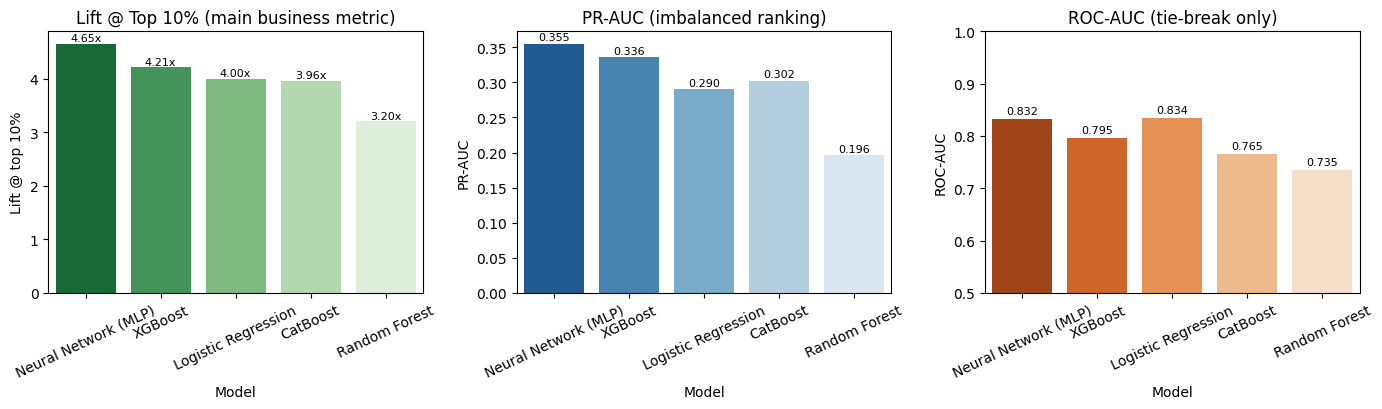

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
sns.barplot(data=comparison, x="Model", y="Lift @ top 10%", ax=ax, palette="Greens_r")
ax.set_title("Lift @ Top 10% (main business metric)")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(comparison["Lift @ top 10%"]):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center", fontsize=8)

ax = axes[1]
sns.barplot(data=comparison, x="Model", y="PR-AUC", ax=ax, palette="Blues_r")
ax.set_title("PR-AUC (imbalanced ranking)")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(comparison["PR-AUC"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)

ax = axes[2]
sns.barplot(data=comparison, x="Model", y="ROC-AUC", ax=ax, palette="Oranges_r")
ax.set_title("ROC-AUC (tie-break only)")
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(comparison["ROC-AUC"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


In [18]:
if best_name == "XGBoost":
    best_clf, best_proba, best_preprocess = clf_xgb, proba_xgb, preprocess_tree
elif best_name == "CatBoost":
    best_clf, best_proba, best_preprocess = clf_cat, proba_cat, preprocess_tree
elif best_name == "Random Forest":
    best_clf, best_proba, best_preprocess = clf_rf, proba_rf, preprocess_tree
elif best_name == "Neural Network (MLP)":
    best_clf, best_proba, best_preprocess = clf_mlp, proba_mlp, preprocess_linear
else:
    best_clf, best_proba, best_preprocess = clf_lr, proba_lr, preprocess_linear

proba = best_proba
clf = best_clf
preprocess = best_preprocess
print(f"Selected for production pipeline: {best_name}")


Selected for production pipeline: Neural Network (MLP)


## 10. Threshold Tuning & Lift Detail (Best Model)

In [19]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
f1 = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.nanargmax(f1)
best_thr = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Best model: {best_name}")
print(f"F1-optimal threshold: {best_thr:.3f}  (precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f})")
print()
print(classification_report(y_test, (proba >= best_thr).astype(int), digits=3))

print("\n=== Confusion at different thresholds ===")
for thr in [0.5, 0.4, 0.3, 0.2]:
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"thr={thr:.1f}  TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  "
          f"Precision={tp/(tp+fp+1e-9):.3f}  Recall={tp/(tp+fn+1e-9):.3f}")

print(f"\nBase late rate = {y_test.mean():.1%}")
print("--- Business ranking quality ---")
for top_pct in [0.05, 0.10, 0.15, 0.20, 0.30]:
    k = max(1, int(len(proba) * top_pct))
    top_idx = np.argsort(proba)[::-1][:k]
    captured = y_test.values[top_idx].sum() / y_test.sum()
    print(f"Top {int(top_pct*100):2d}% riskiest -> captures {captured*100:5.1f}% of delays  "
          f"(lift = {captured/top_pct:.2f}x)")


Best model: Neural Network (MLP)
F1-optimal threshold: 0.451  (precision=0.383, recall=0.305)

              precision    recall  f1-score   support

           0      0.963     0.973     0.968     20794
           1      0.383     0.305     0.339      1133

    accuracy                          0.939     21927
   macro avg      0.673     0.639     0.654     21927
weighted avg      0.933     0.939     0.935     21927


=== Confusion at different thresholds ===
thr=0.5  TP= 313  FP= 414  FN= 820  Precision=0.431  Recall=0.276
thr=0.4  TP= 372  FP= 721  FN= 761  Precision=0.340  Recall=0.328
thr=0.3  TP= 465  FP=1229  FN= 668  Precision=0.274  Recall=0.410
thr=0.2  TP= 606  FP=2211  FN= 527  Precision=0.215  Recall=0.535

Base late rate = 5.2%
--- Business ranking quality ---
Top  5% riskiest -> captures  32.8% of delays  (lift = 6.57x)
Top 10% riskiest -> captures  46.5% of delays  (lift = 4.65x)
Top 15% riskiest -> captures  57.2% of delays  (lift = 3.81x)
Top 20% riskiest -> captures 

## 11. Walk-Forward Validation (Best Model)

In [20]:
def make_best_model():
    if best_name == "XGBoost":
        return XGBClassifier(**xgb_search.best_params_, objective="binary:logistic",
                             eval_metric="aucpr", tree_method="hist", random_state=42, n_jobs=-1)
    elif best_name == "CatBoost":
        p = dict(cat_search.best_params_)
        return CatBoostClassifier(**p, verbose=False, random_seed=42)
    elif best_name == "Random Forest":
        return RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
    elif best_name == "Neural Network (MLP)":
        return MLPClassifier(**mlp_search.best_params_, random_state=42,
                             early_stopping=True, validation_fraction=0.1)
    else:
        return LogisticRegression(**lr_search.best_params_, random_state=42, n_jobs=-1)

use_linear = best_name in ["Neural Network (MLP)", "Logistic Regression"]

model_df_sorted = model_df.sort_values("order_purchase_timestamp").reset_index(drop=True)
n = len(model_df_sorted)
edges = np.linspace(0.50, 1.0, 6)

wf = []
for i in range(len(edges) - 1):
    tr_end, te_end = int(n * edges[i]), int(n * edges[i + 1])
    ftrain = model_df_sorted.iloc[:tr_end]
    ftest  = model_df_sorted.iloc[tr_end:te_end]
    if ftest["is_late"].nunique() < 2:
        continue
    pre = ColumnTransformer([
        ("num", StandardScaler() if use_linear else "passthrough", FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=40, sparse_output=False), FEATURES_CAT),
    ])
    Xf_tr = pre.fit_transform(ftrain[FEATURES_NUM + FEATURES_CAT])
    Xf_te = pre.transform(ftest[FEATURES_NUM + FEATURES_CAT])
    yf_tr = ftrain["is_late"].astype(int)
    yf_te = ftest["is_late"].astype(int)
    m = make_best_model()
    m.fit(Xf_tr, yf_tr)
    p = m.predict_proba(Xf_te)[:, 1]
    k = max(1, int(len(p) * 0.10))
    top_idx = np.argsort(p)[::-1][:k]
    lift10 = (yf_te.values[top_idx].sum() / max(yf_te.sum(), 1)) / 0.10
    wf.append({
        "fold": i, "n_test": len(ftest),
        "late_rate": round(yf_te.mean(), 3),
        "roc_auc": round(roc_auc_score(yf_te, p), 3),
        "pr_auc": round(average_precision_score(yf_te, p), 3),
        "lift_top10": round(lift10, 2),
    })

wf_df = pd.DataFrame(wf)
print(f"Walk-forward for: {best_name}")
print(wf_df.to_string(index=False))
print(f"\nMean ROC-AUC : {wf_df['roc_auc'].mean():.3f} ± {wf_df['roc_auc'].std():.3f}")
print(f"Mean PR-AUC  : {wf_df['pr_auc'].mean():.3f} ± {wf_df['pr_auc'].std():.3f}")
print(f"Mean Lift@10%: {wf_df['lift_top10'].mean():.2f}x ± {wf_df['lift_top10'].std():.2f}")


Walk-forward for: Neural Network (MLP)
 fold  n_test  late_rate  roc_auc  pr_auc  lift_top10
    0   10963      0.149    0.753   0.402       2.970
    1   10963      0.149    0.773   0.393       2.940
    2   10964      0.071    0.805   0.322       4.110
    3   10963      0.019    0.836   0.409       5.470
    4   10964      0.084    0.800   0.377       3.900

Mean ROC-AUC : 0.793 ± 0.032
Mean PR-AUC  : 0.381 ± 0.035
Mean Lift@10%: 3.88x ± 1.04


## 12. Regression — Predict Days Late (XGBoost)

In [21]:
y_train_reg = train_df["delivery_delay_days"]
y_test_reg  = test_df["delivery_delay_days"]

def objective_reg(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "tree_method": "hist", "random_state": 42, "n_jobs": -1,
    }
    cut = int(0.8 * len(Xtr))
    m = XGBRegressor(**params)
    m.fit(Xtr[:cut], y_train_reg.iloc[:cut], verbose=False)
    pred = m.predict(Xtr[cut:])
    return -mean_absolute_error(y_train_reg.iloc[cut:], pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective_reg, n_trials=20, show_progress_bar=True)

reg_params = dict(study.best_params)
reg_params.update({"tree_method": "hist", "random_state": 42, "n_jobs": -1})
reg = XGBRegressor(**reg_params)
reg.fit(Xtr, y_train_reg, verbose=False)
pred_days = reg.predict(Xte)

print(f"MAE  (days): {mean_absolute_error(y_test_reg, pred_days):.3f}")
print(f"RMSE (days): {np.sqrt(mean_squared_error(y_test_reg, pred_days)):.3f}")
print(f"R2         : {r2_score(y_test_reg, pred_days):.3f}")


  0%|          | 0/20 [00:00<?, ?it/s]

MAE  (days): 4.841
RMSE (days): 6.142
R2         : 0.607


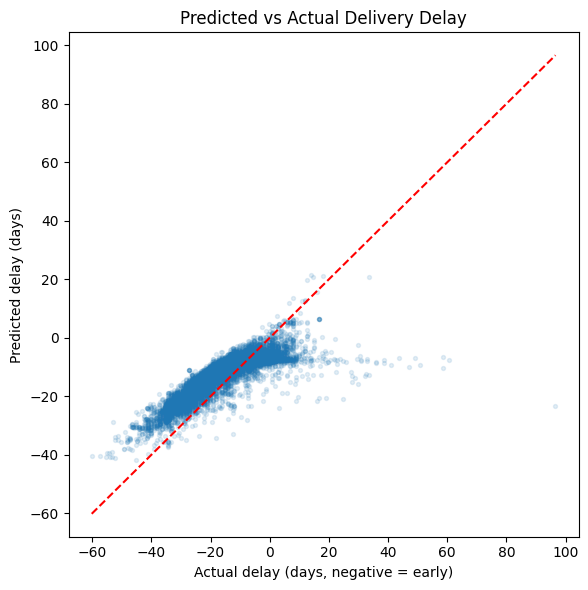

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_days, alpha=0.12, s=8)
lims = [min(y_test_reg.min(), pred_days.min()), max(y_test_reg.max(), pred_days.max())]
plt.plot(lims, lims, "--", color="red", lw=1.5)
plt.xlabel("Actual delay (days, negative = early)")
plt.ylabel("Predicted delay (days)")
plt.title("Predicted vs Actual Delivery Delay")
plt.tight_layout()
plt.show()


## 13. Feature Importance (Best Model)

In [23]:
feat_names = FEATURES_NUM + list(
    preprocess_tree.named_transformers_["cat"].get_feature_names_out(FEATURES_CAT)
)

if best_name in ["XGBoost", "CatBoost", "Random Forest"]:
    if best_name == "XGBoost":
        imp_vals = clf_xgb.feature_importances_
    elif best_name == "CatBoost":
        imp_vals = np.array(clf_cat.get_feature_importance())
        if len(imp_vals) != len(feat_names):
            feat_names = [f"f{i}" for i in range(len(imp_vals))]
    else:
        imp_vals = clf_rf.feature_importances_
    imp = pd.DataFrame({"Feature": feat_names[:len(imp_vals)], "Importance": imp_vals}).sort_values(
        "Importance", ascending=False
    )
    print(f"Top 15 features ({best_name}):")
    print(imp.head(15).to_string(index=False))
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp.head(10).iloc[::-1], y="Feature", x="Importance", palette="Blues_r")
    plt.title(f"Top 10 Features — {best_name}")
    plt.tight_layout()
    plt.show()
elif best_name == "Logistic Regression":
    coef = np.abs(clf_lr.coef_[0])
    n = min(len(coef), len(feat_names))
    imp = pd.DataFrame({"Feature": feat_names[:n], "Importance": coef[:n]}).sort_values(
        "Importance", ascending=False
    )
    print("Top 15 features (Logistic Regression |coef|):")
    print(imp.head(15).to_string(index=False))
else:
    print("MLP has no native feature importance. Use coefficients / SHAP if needed.")


MLP has no native feature importance. Use coefficients / SHAP if needed.


## 14. SHAP Explainability (Tree / Boosting Models)

In [24]:
import shap

if best_name in ["XGBoost", "Random Forest", "CatBoost"]:
    try:
        explainer = shap.TreeExplainer(best_clf)
        sample_idx = np.random.choice(Xte.shape[0], size=min(1000, Xte.shape[0]), replace=False)
        shap_vals = explainer.shap_values(Xte[sample_idx])
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        plt.figure(figsize=(10, 7))
        shap.summary_plot(shap_vals, Xte[sample_idx], feature_names=feat_names, show=False)
        plt.title(f"SHAP Summary — {best_name}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print(f"SHAP TreeExplainer not applied to {best_name}.")


SHAP TreeExplainer not applied to Neural Network (MLP).


## 15. Delay Risk Report (Best Model)

In [25]:
FRIENDLY = {
    "carrier_pickup_days": "slow seller handling / carrier pickup",
    "customer_seller_distance_km": "long distance between customer and seller",
    "seller_hist_late_rate": "seller's history of late deliveries",
    "seller_recent_late_rate": "seller's recent (30-day) late deliveries",
    "promised_delivery_days": "very tight promised delivery window",
    "order_item_count": "order contains many items",
    "freight_value": "high shipping cost",
    "freight_percentage": "high shipping cost relative to order value",
    "approval_days": "slow payment approval",
    "purchase_month": "seasonal high-demand period",
    "is_holiday_season": "holiday season order",
    "product_weight_g": "heavy product",
}

def friendly(fname):
    if fname in FRIENDLY:
        return FRIENDLY[fname]
    for prefix, label in [("category_", "category"), ("customer_state_", "customer state"),
                          ("seller_state_", "seller state"), ("main_payment_type_", "payment"),
                          ("distance_category_", "distance")]:
        if fname.startswith(prefix):
            return f"{label} = {fname[len(prefix):]}"
    return fname.replace("_", " ")

reasons = ["See feature importance"] * len(proba)
if best_name in ["XGBoost", "Random Forest", "CatBoost"]:
    try:
        shap_full = explainer.shap_values(Xte)
        if isinstance(shap_full, list):
            shap_full = shap_full[1]
        reasons = []
        for row in shap_full:
            pos = np.where(row > 0)[0]
            if len(pos) == 0:
                reasons.append("No major risk factors")
            else:
                reasons.append(friendly(feat_names[pos[np.argmax(row[pos])]]).capitalize())
    except Exception:
        pass

rank_pct = pd.Series(proba).rank(pct=True, ascending=False).values
def band(p):
    if p <= 0.05: return "Critical"
    if p <= 0.20: return "High"
    if p <= 0.50: return "Medium"
    return "Low"

report = pd.DataFrame({
    "Order ID": test_df["order_id"].values,
    "Purchase Date": test_df["order_purchase_timestamp"].dt.date.values,
    "Category": test_df["category"].values,
    "Customer State": test_df["customer_state"].values,
    "Seller State": test_df["seller_state"].values,
    "Order Value (R$)": test_df["order_value"].round(2).values,
    "Distance (km)": test_df["customer_seller_distance_km"].round(0).values,
    "Late Risk (%)": (proba * 100).round(1),
    "Risk Level": [band(p) for p in rank_pct],
    "Predicted Delay (days)": np.round(pred_days, 1),
    "Main Risk Factor": reasons,
    "Actually Late?": np.where(y_test.values == 1, "Yes", "No"),
})
report = (
    report.loc[report.groupby("Order ID")["Late Risk (%)"].idxmax()]
    .sort_values("Late Risk (%)", ascending=False, kind="mergesort")
    .reset_index(drop=True)
)
report.insert(0, "Rank", range(1, len(report) + 1))

print(f"Best model used: {best_name}")
print(f"Risk report: {len(report)} unique orders")
display(report.head(12))

os.makedirs("/kaggle/working", exist_ok=True)
report.to_csv("/kaggle/working/delay_risk_report.csv", index=False)
print("Saved delay_risk_report.csv")


Best model used: Neural Network (MLP)
Risk report: 19314 unique orders


,Rank,Order ID,Purchase Date,Category,Customer State,Seller State,Order Value (R$),Distance (km),Late Risk (%),Risk Level,Predicted Delay (days),Main Risk Factor,Actually Late?
0,1,2efe3d3b0ddc295d2ce1c43f021078cb,2018-07-29,garden_tools,SP,SP,17.170,9.000,100.000,Critical,6.500,See feature importance,Yes
1,2,4505acb3759da6b9c7d79a80d29ab3bb,2018-08-06,furniture_decor,SP,SP,42.500,22.000,100.000,Critical,20.700,See feature importance,Yes
2,3,734e66350ff1d845ab707409554c76c4,2018-08-03,sports_leisure,RS,SP,235.060,810.000,100.000,Critical,21.200,See feature importance,Yes
3,4,3816ba21917f2a17a58a38a108985d0c,2018-07-14,health_beauty,SP,MA,94.740,2354.000,99.900,Critical,5.400,See feature importance,Yes
4,5,3b43a1faa9745dfcd8ef87937f4cab08,2018-07-11,health_beauty,SP,MA,94.740,2356.000,99.900,Critical,8.300,See feature importance,Yes
5,6,628111ec0fcace16f3112336b1138aef,2018-07-14,health_beauty,SP,MA,94.740,2360.000,99.900,Critical,5.400,See feature importance,Yes
6,7,6c353b764e0d5e28cb2852e8e8603def,2018-07-14,health_beauty,SE,MA,144.120,1228.000,99.900,Critical,5.500,See feature importance,Yes
7,8,a4ca2ef2db84bd36005b60249c9600d7,2018-07-14,health_beauty,SP,MA,94.740,2289.000,99.900,Critical,4.800,See feature importance,Yes
8,9,a98f79318168a3b20eca9c4530909f49,2018-07-11,bed_bath_table,SP,SP,840.630,91.000,99.900,Critical,20.800,See feature importance,Yes
9,10,14def5e6b6021ae117c181c039258033,2018-07-25,watches_gifts,SP,SP,180.460,14.000,99.800,Critical,19.700,See feature importance,Yes


Saved delay_risk_report.csv


## 16. Category, Route & Seller Insights

In [26]:
from statsmodels.stats.proportion import proportions_ztest

def sig_groups(df, col, min_n=80, alpha=0.05):
    overall = df["is_late"].mean()
    rows = []
    for name, g in df.groupby(col):
        n = len(g)
        if n < min_n:
            continue
        late = int(g["is_late"].sum())
        rate = late / n
        _, pval = proportions_ztest(late, n, value=overall, alternative="larger")
        if pval < alpha:
            rows.append({col: name, "n_orders": n, "late_rate": round(rate, 4),
                         "lift": round(rate / overall, 2), "p_value": round(pval, 4)})
    return pd.DataFrame(rows).sort_values("late_rate", ascending=False)

cat_tbl = sig_groups(model_df, "category", min_n=100)
route_tbl = sig_groups(
    model_df.assign(route=model_df["seller_state"] + "->" + model_df["customer_state"]),
    "route", min_n=80
)
seller_tbl = (
    model_df.groupby("seller_id")
    .agg(n_orders=("order_id", "nunique"), late_rate=("is_late", "mean"),
         avg_delay=("delivery_delay_days", "mean"))
    .query("n_orders >= 30")
    .sort_values("late_rate", ascending=False).head(25).reset_index()
)

print("=== High-risk categories ===")
display(cat_tbl.head(10))
print("\n=== High-risk routes ===")
display(route_tbl.head(10))
print("\n=== High-late-rate sellers (min 30 orders) ===")
display(seller_tbl.head(10))


=== High-risk categories ===


,category,n_orders,late_rate,lift,p_value
0,audio,361,0.127,1.610,0.003
2,electronics,2636,0.095,1.210,0.002
5,unknown,1530,0.094,1.190,0.021
4,health_beauty,9435,0.090,1.140,0.000
3,furniture_decor,8137,0.084,1.070,0.042
1,bed_bath_table,10925,0.084,1.060,0.031



=== High-risk routes ===


,route,n_orders,late_rate,lift,p_value
0,MA->SP,130,0.269,3.410,0.000
5,SP->AL,273,0.253,3.200,0.000
9,SP->MA,544,0.221,2.790,0.000
17,SP->SE,236,0.182,2.310,0.000
13,SP->PI,359,0.178,2.260,0.000
1,MG->PA,92,0.174,2.200,0.008
7,SP->CE,1083,0.155,1.960,0.000
2,PR->BA,163,0.153,1.940,0.004
14,SP->RJ,9373,0.148,1.880,0.000
6,SP->BA,2609,0.147,1.860,0.000



=== High-late-rate sellers (min 30 orders) ===


,seller_id,n_orders,late_rate,avg_delay
0,ede0c03645598cdfc63ca8237acbe73d,43,0.340,-3.484
1,54965bbe3e4f07ae045b90b0b8541f52,73,0.321,-1.687
2,ad781527c93d00d89a11eecd9dcad7c1,38,0.316,-8.314
3,835f0f7810c76831d6c7d24c7a646d4d,42,0.312,-4.968
4,2a1348e9addc1af5aaa619b1a3679d6b,48,0.294,1.354
5,66e0557ecc2b4dbea057e93f215f68d8,30,0.267,-8.132
6,71039d19d4303bf9054d69e9a9236699,35,0.263,-6.550
7,6039e27294dc75811c0d8a39069f52c0,63,0.257,-6.374
8,a49928bcdf77c55c6d6e05e09a9b4ca5,96,0.250,-3.813
9,ef990a83bbea832f36ebe81376335aa8,43,0.250,-7.806


## 17. Save Models & Artifacts

In [27]:
import joblib
out = "/kaggle/working/models_delay_business"
os.makedirs(out, exist_ok=True)

joblib.dump(clf_xgb, f"{out}/clf_xgboost.pkl")
joblib.dump(clf_cat, f"{out}/clf_catboost.pkl")
joblib.dump(clf_rf, f"{out}/clf_random_forest.pkl")
joblib.dump(clf_mlp, f"{out}/clf_mlp.pkl")
joblib.dump(clf_lr, f"{out}/clf_logistic.pkl")
joblib.dump(best_clf, f"{out}/clf_best.pkl")
joblib.dump(reg, f"{out}/reg_delay_days.pkl")
joblib.dump(preprocess_tree, f"{out}/preprocess_tree.pkl")
joblib.dump(preprocess_linear, f"{out}/preprocess_linear.pkl")

comparison.to_csv(f"{out}/model_comparison.csv", index=False)
wf_df.to_csv(f"{out}/walk_forward_results.csv", index=False)
cat_tbl.to_csv(f"{out}/category_delay_table.csv", index=False)
route_tbl.to_csv(f"{out}/route_delay_table.csv", index=False)
seller_tbl.to_csv(f"{out}/seller_scorecard.csv", index=False)
report.to_csv(f"{out}/delay_risk_report.csv", index=False)

with open(f"{out}/feature_schema.json", "w") as f:
    json.dump({
        "numeric": FEATURES_NUM,
        "categorical": FEATURES_CAT,
        "best_model": best_name,
        "selection_rule": "Lift@10% > PR-AUC > ROC-AUC",
        "best_threshold": float(best_thr),
        "model_comparison": comparison.to_dict(orient="records"),
        "walk_forward_mean_roc_auc": float(wf_df["roc_auc"].mean()),
        "walk_forward_mean_pr_auc": float(wf_df["pr_auc"].mean()),
        "walk_forward_mean_lift_top10": float(wf_df["lift_top10"].mean()),
        "regression_mae": float(mean_absolute_error(y_test_reg, pred_days)),
        "regression_r2": float(r2_score(y_test_reg, pred_days)),
    }, f, indent=2)

print("Saved to", out)
print(os.listdir(out))
print(f"\nBest model (business ranking): {best_name}")


Saved to /kaggle/working/models_delay_business
['clf_random_forest.pkl', 'clf_logistic.pkl', 'preprocess_tree.pkl', 'delay_risk_report.csv', 'preprocess_linear.pkl', 'feature_schema.json', 'walk_forward_results.csv', 'model_comparison.csv', 'seller_scorecard.csv', 'clf_mlp.pkl', 'clf_xgboost.pkl', 'reg_delay_days.pkl', 'route_delay_table.csv', 'clf_catboost.pkl', 'category_delay_table.csv', 'clf_best.pkl']

Best model (business ranking): Neural Network (MLP)
